Author: Sabrina Derwent

In [101]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [ ]:
#data_path = "C:\\Users\\akl0407\\OneDrive - Northwestern University\\Back up\\2025-26\\Spring 2025\\STAT390\\LegalAid\\Data\\CAR_-_EP_Flow_Activity_Queue__Agent_Names\\"

In [102]:
data_path = "/Users/sabrinaderwent/Desktop/fall25/stat390/CAR_datasets/"

### User input ends

### Reading all filenames in the data folder

In [103]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [104]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

In [105]:
df_main.head()


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,001a3748-8d50-4550-8461-33547983deb0,Main Number Telephony EP,NaN,NaN,2025/01/14 12:39:32 PM,NaN,NaN,NaN
1,001a3748-8d50-4550-8461-33547983deb0,NaN,LACMain,NaN,2025/01/14 12:39:32 PM,NaN,NaN,NaN
2,001a3748-8d50-4550-8461-33547983deb0,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025/01/14 12:39:32 PM,NaN,NaN,NaN
3,001a3748-8d50-4550-8461-33547983deb0,Main Number Telephony EP,LACMain,NaN,2025/01/14 12:39:32 PM,NaN,NaN,NaN
4,001a3748-8d50-4550-8461-33547983deb0,Main Number Telephony EP,NaN,MainMenu,2025/01/14 12:39:45 PM,NaN,NaN,NaN


### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [106]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [107]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
dtype: object

In [108]:
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

In [109]:
df_main["date"] = df_main["Activity Start Timestamp"].dt.date
df_main["date"] = pd.to_datetime(df_main["date"])

#### Exploring Menu Options in Call Journey

In [ ]:
df_main["Termination Reason"].unique()
#df_main["EP Name"].unique()
#df_main["Activity Name"].unique()
#df_main["Flow Name"].unique()


For presentation 1, I spent a lot of time tyring to conceptualize what a call journey looks like, as the dataset can sometimes be ambiguous. For the next presentation, my goal is to develop a systematic way to trace a call journey despite some confusing journeys

### Filtering Dataset

In [110]:
# filtering dataset so that I only have datapoints that contain the "Termination Reason" column
start_date = "2025-03-16"
end_date = "2025-09-30"
df_short = df_main[(df_main['date'] >= start_date) & (df_main["date"] <= end_date)]

## Presentation 2: Analyzing Termination Reason

In [ ]:
# looking at how many calls have a what termination reason
df_short.groupby( "Termination Reason").nunique()

In [ ]:
# creating a long dataframe that lists each step in the same column

df_long = (
    df.melt(
        id_vars=['Contact Session ID', "Activity Start Timestamp"],
        value_vars = ['EP Name', 'Flow Name', 'Activity Name', 'Queue Name', 'Termination Reason', 'Agent Name'],
        var_name='Step Category',
        value_name='Activity'
    )
    .dropna(subset=['Activity'])
    .set_index("Contact Session ID")
)


In [ ]:
# making sure dataframe is in chronological order
df_long = df_long.sort_values(by=["Contact Session ID", "Activity Start Timestamp"])
df_long.head(100)

### Looking at Number of Calls with 'Customer Left"
This termination reason is focused on more in depth by EDA team 1, so this I didn't do analysis for this reason

In [ ]:
# get the last row per session
last_steps = df_long.groupby('Contact Session ID').tail(1)

# filter by desired end condition
ended_hangup = last_steps[last_steps['Activity'] == 'Customer Left']

# get the full journey for those calls
filtered_journeys = df_long[df_long['Contact Session ID'].isin(ended_hangup['Contact Session ID'])]

filtered_journeys.groupby("Contact Session ID").nth(3)

### Looking at Calls with 'Queue Timeout'

In [ ]:
# filter by desired end condition
queue_time = df_long[df_long['Activity'] == 'Queue Timeout']

# get the full journey for those calls
filtered_journeys = df_long[df_long['Contact Session ID'].isin(queue_time['Contact Session ID'])]

filtered_journeys.groupby("Contact Session ID").tail()




In [ ]:
# journey of this call - I chose this call because it demonstrates a Queue Timeout and multiple courtesy callbacks
filtered_journeys[filtered_journeys['Contact Session ID'] == "0d5dec0a-ec28-4bb0-a728-5f848b543d8d"]

#### Looking at Courtesy Calls after the call originally reaches 'Queue Timeout'

In [ ]:
# example of how to manually get the number of courtesy callbacks  
filtered_journeys[(filtered_journeys['Contact Session ID'] == "0d5dec0a-ec28-4bb0-a728-5f848b543d8d")
                    & (filtered_journeys['Activity'] == "Courtesy Callback Telephony EP")]

In [ ]:
# number of cortesy callbacks

callback = df_long[df_long['Activity'] == 'Courtesy Callback Telephony EP']

# get the full journey for those calls
filtered_journeys = df_long[df_long['Contact Session ID'].isin(callback['Contact Session ID'])]

filtered_journeys.groupby("Contact Session ID").nunique()

### Looking at calls with 'Agent Left'
I determined that this termination reason can solely be classified as positive.

In [ ]:
last_steps = df_long.groupby('Contact Session ID').tail(1)

# filter by desired end condition
ended_agent = last_steps[last_steps['Activity'] == 'Agent Left']

# get the full journey for those calls
filtered_journeys = df_long[df_long['Contact Session ID'].isin(ended_agent['Contact Session ID'])]

filtered_journeys.groupby("Contact Session ID").tail(2)

In [ ]:
filtered_journeys[filtered_journeys['Contact Session ID'] == "008d1660-7605-44ca-a9b3-11b8f81e61f3"]

### Looking at Calls with 'System disconnected the contact'
I determined that these calls can be solely classified as neutral.

In [ ]:
last_steps = df_long.groupby('Contact Session ID').tail(1)

# filter by desired end condition
system_dis = last_steps[last_steps['Activity'] == 'System disconnected the contact']

# get the full journey for those calls
filtered_journeys = df_long[df_long['Contact Session ID'].isin(system_dis['Contact Session ID'])]

filtered_journeys.groupby("Contact Session ID").nth(2)

In [ ]:
filtered_journeys[filtered_journeys['Contact Session ID']== "fdc56f2f-75b9-4642-8fcb-f05b7ba668b8"]

## Presentation 3: Assigning Call Outcomes

In this analysis, I am using the ideas for how to assign a call outcome in presentation 2. Our team decided to split it up by menu, so I am tagging the calls that primarily track in the housing menu.

In [111]:
# find all Contact Session IDs where Housing Menu appears at any point
house = df_long.loc[df_long['Activity'] == 'HousingMenu']

# extract session ids from index
house_ids = house.index.unique()

# # pull full journeys for only those calls
df_house = df_long.loc[df_long.index.isin(house_ids)]

df_house.tail(50)


,Activity Start Timestamp,Step Category,Activity
Contact Session ID,,,
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:44 AM,Activity Name,PreQueueMessage2
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:44 AM,Queue Name,Consumer
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:44 AM,Queue Name,Consumer
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:49 AM,EP Name,Courtesy Callback Telephony EP
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:49 AM,Flow Name,CourtesyCallback
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:49 AM,Activity Name,ReadANI
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:52 AM,EP Name,Courtesy Callback Telephony EP
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:52 AM,Activity Name,CollectCallbackNumber
ffb45974-d509-4750-bba1-b59f22e76242,2025/03/25 08:02:59 AM,EP Name,Courtesy Callback Telephony EP


In [112]:
df_house.groupby('Contact Session ID').count()

,Activity Start Timestamp,Step Category,Activity
Contact Session ID,,,
022e8491-bde1-45f9-8a1a-e2a2def63a0e,33,33,33
024e2e63-c316-4506-9cb3-297d79288753,35,35,35
0296fe15-e3c3-4673-a92e-efcdcab2fb43,29,29,29
02f34d1c-9a1a-4310-9fc7-decbea3ce6b9,41,41,41
04b8cb3c-1e9f-47ef-a412-d4eb45620ed4,53,53,53
...,...,...,...
fe493554-44a1-49bf-a2e4-ec2e1684130d,29,29,29
fea95469-059e-4cf8-8869-cc18081c9c1a,66,66,66
fed8ef04-51cc-4235-bc42-070d9f81641a,32,32,32


There are 289 calls that navigate to the housing menu at any point in their journey

In [113]:
# filter out only the rows with termination reason
term_reason = df_house[df_house['Step Category'] == "Termination Reason"]


In [114]:
# print the termination reasons for the contact session id
for session_id, group in term_reason.groupby('Contact Session ID'):
    print(f"Session {session_id}")
    print(group, "\n")


Session 022e8491-bde1-45f9-8a1a-e2a2def63a0e
                                     Activity Start Timestamp  \
Contact Session ID                                              
022e8491-bde1-45f9-8a1a-e2a2def63a0e   2025/03/24 09:52:52 AM   

                                           Step Category       Activity  
Contact Session ID                                                       
022e8491-bde1-45f9-8a1a-e2a2def63a0e  Termination Reason  Customer Left   

Session 024e2e63-c316-4506-9cb3-297d79288753
                                     Activity Start Timestamp  \
Contact Session ID                                              
024e2e63-c316-4506-9cb3-297d79288753   2025/03/25 12:49:45 PM   

                                           Step Category       Activity  
Contact Session ID                                                       
024e2e63-c316-4506-9cb3-297d79288753  Termination Reason  Customer Left   

Session 0296fe15-e3c3-4673-a92e-efcdcab2fb43
                         

In [115]:
queue_name = df_house[df_house['Step Category'] == "Queue Name"]

In [116]:
consumer = []
housing = []
voicemail = []

# Loop through each call journey
for session_id, group in queue_name.groupby('Contact Session ID'):

    # Check for Consumer queues
    if group['Activity'].isin(["Consumer", "Consumer SP"]).any():
        consumer.append(df_house.loc[session_id, :])

    # Check for Housing queues
    if group['Activity'].isin(["Housing", "Housing SP"]).any():
        housing.append(df_house.loc[session_id, :])

    # Check for Clinic Voicemail
    if group['Activity'].eq("Clinic Voicemail Transfer").any():
        voicemail.append(df_house.loc[session_id, :])

df_consumer = pd.concat(consumer)
df_housing = pd.concat(housing)
df_voicemail = pd.concat(voicemail)


In [117]:

df_house['is_positive'] = (
    (df_house['Step Category'] == 'Agent Name') |
    (df_house['Activity'] == 'Agent Left') |
    (df_house['Activity'] == 'AGENT_ENDS')
)


In [118]:
df_house['is_neutral'] =  (
    (df_house['Activity'] == 'NO_ANSWER_FROM_CUSTOMER') |
    (df_house['Activity'] == 'CUSTOMER_BUSY') |
    (df_house['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_house['Activity'] == 'Participant Invite timer expired') |
    (df_house['Activity'] == 'CUSTOMER_UNAVAILABLE') |
    (df_house['Activity'] == 'USER_DECLINED') |
    (df_house['Activity'] == 'USER_BUSY') |
    (df_house['Activity'] == 'NO_ANSWER_USER') 


)


In [119]:
df_house['is_negative'] = (
(df_house['Activity'] == 'AGENT_UNAVAILABLE') |
    (df_house['Activity'] == 'AGENT_BUSY') |
    (df_house['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_house['Activity'] == 'NO_ANSWER_FROM_AGENT') |
    (df_house['Activity'] == 'OUTDIAL_FAILED') |
    (df_house['Activity'] == 'MEDIA_MANAGER_INTERNAL_ERROR') |
    (df_house['Activity'] == 'CHANNEL_FAILURE')

)

In [120]:
# Group by session and collect all applicable tags
session_flags = df_house.groupby('Contact Session ID').agg({
    'is_positive': 'max',  # True if any row in session is positive
    'is_neutral': 'max',   # True if any row is neutral
    'is_negative': 'max',  # True if any row is negative
})

# Create a list of outcomes for each session
def collect_outcomes(row):
    outcomes = []
    if row['is_positive']:
        outcomes.append('Positive')
    if row['is_neutral']:
        outcomes.append('Neutral')
    if row['is_negative']:
        outcomes.append('Negative')
    if not outcomes:
        outcomes.append('Negative')
    return ', '.join(outcomes)

session_flags['Outcome'] = session_flags.apply(collect_outcomes, axis=1)


In [121]:
# Keep Outcome as a DataFrame
session_outcome = session_flags[['Outcome']].copy()

# Merge back to original DataFrame
df_house = df_house.merge(
    session_outcome,
    how='left',
    left_on='Contact Session ID',
    right_index=True
)

# Optional: drop temporary flags
df_house.drop(columns=['is_positive', 'is_neutral', 'is_negative'], inplace = True)



In [122]:
counts = df_house.groupby("Contact Session ID")['Outcome'].nth(1)
counts = pd.DataFrame(counts)
# neg = counts[0]/sum(counts)
# pos = counts[1]/sum(counts)
# print(counts)
# print("Negative:", neg)
# print("Positive:", pos)
counts

,Outcome
Contact Session ID,
022e8491-bde1-45f9-8a1a-e2a2def63a0e,Negative
024e2e63-c316-4506-9cb3-297d79288753,Negative
0296fe15-e3c3-4673-a92e-efcdcab2fb43,Negative
02f34d1c-9a1a-4310-9fc7-decbea3ce6b9,Positive
04b8cb3c-1e9f-47ef-a412-d4eb45620ed4,Negative
...,...
fe493554-44a1-49bf-a2e4-ec2e1684130d,Negative
fea95469-059e-4cf8-8869-cc18081c9c1a,Positive
fed8ef04-51cc-4235-bc42-070d9f81641a,Negative


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

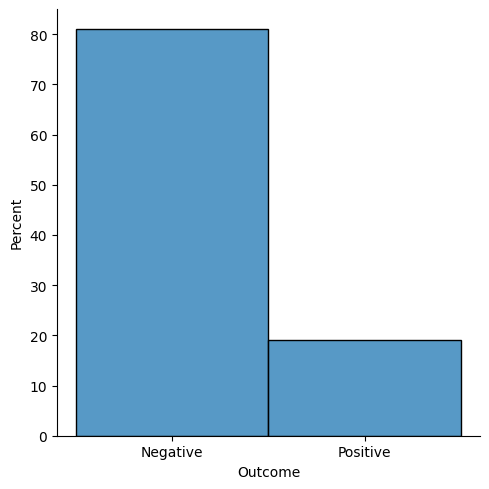

In [123]:
sns.displot(counts, x="Outcome", stat = "percent")
plt.plot

### Call Outcomes by Queue Selection

In [124]:
df_consumer = pd.concat(consumer)
df_housing = pd.concat(housing)
df_voicemail = pd.concat(voicemail)

#### Consumer Queue

In [129]:

df_consumer['is_positive'] = (
    (df_consumer['Step Category'] == 'Agent Name') |
    (df_consumer['Activity'] == 'Agent Left') |
    (df_consumer['Activity'] == 'AGENT_ENDS')
)

df_consumer['is_neutral'] =  (
    (df_consumer['Activity'] == 'NO_ANSWER_FROM_CUSTOMER') |
    (df_consumer['Activity'] == 'CUSTOMER_BUSY') |
    (df_consumer['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_consumer['Activity'] == 'Participant Invite timer expired') |
    (df_consumer['Activity'] == 'CUSTOMER_UNAVAILABLE') |
    (df_consumer['Activity'] == 'USER_DECLINED') |
    (df_consumer['Activity'] == 'USER_BUSY') |
    (df_consumer['Activity'] == 'NO_ANSWER_USER') 


)

df_consumer['is_negative'] = (
(df_consumer['Activity'] == 'AGENT_UNAVAILABLE') |
    (df_consumer['Activity'] == 'AGENT_BUSY') |
    (df_consumer['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_consumer['Activity'] == 'NO_ANSWER_FROM_AGENT') |
    (df_consumer['Activity'] == 'OUTDIAL_FAILED') |
    (df_consumer['Activity'] == 'MEDIA_MANAGER_INTERNAL_ERROR') |
    (df_consumer['Activity'] == 'CHANNEL_FAILURE')

)

In [130]:
# Group by session and collect all applicable tags
session_flags_con= df_consumer.groupby('Contact Session ID').agg({
    'is_positive': 'max',  # True if any row in session is positive
    'is_neutral': 'max',   # True if any row is neutral
    'is_negative': 'max',  # True if any row is negative
})

# Create a list of outcomes for each session
def collect_outcomes(row):
    outcomes = []
    if row['is_positive']:
        outcomes.append('Positive')
    if row['is_neutral']:
        outcomes.append('Neutral')
    if row['is_negative']:
        outcomes.append('Negative')
    if not outcomes:
        outcomes.append('Negative')
    return ', '.join(outcomes)

session_flags_con['Outcome'] = session_flags_con.apply(collect_outcomes, axis=1)

In [131]:
session_outcome_con = session_flags_con[['Outcome']].copy()

# Merge back to original DataFrame
df_consumer = df_consumer.merge(
    session_outcome,
    how='left',
    left_on='Contact Session ID',
    right_index=True
)

# Optional: drop temporary flags
df_consumer.drop(columns=['is_positive', 'is_neutral', 'is_negative'], inplace = True)
session_outcome_con

,Outcome
Contact Session ID,
08e25efb-e662-4319-acba-4a34468b68c7,Positive
205faa14-9096-4efd-b383-52e815047817,Positive
a5169285-54f1-4dbe-a45e-af9fd3ce989e,Positive
bff44901-9610-4c24-84f3-c3e1e92c2608,Negative
e09269a7-231a-4fc7-b1ba-21c0fa1161f8,Positive
e0decd02-a077-4f51-a8f7-ccf629205141,Positive
ee474fec-7cc4-443c-b2f8-ac16513ba82b,Positive
f20351c7-420f-426f-aed7-648d15133cb9,Positive
fea95469-059e-4cf8-8869-cc18081c9c1a,Positive


In [135]:

counts_con = df_consumer.groupby("Contact Session ID")['Outcome'].nth(1).value_counts()
counts_con
# counts_con = pd.DataFrame(counts)
# counts_con

Outcome
Positive    9
Negative    1
Name: count, dtype: int64

#### Housing Queue

In [137]:

df_housing['is_positive'] = (
    (df_housing['Step Category'] == 'Agent Name') |
    (df_housing['Activity'] == 'Agent Left') |
    (df_housing['Activity'] == 'AGENT_ENDS')
)

df_housing['is_neutral'] =  (
    (df_housing['Activity'] == 'NO_ANSWER_FROM_CUSTOMER') |
    (df_housing['Activity'] == 'CUSTOMER_BUSY') |
    (df_housing['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_housing['Activity'] == 'Participant Invite timer expired') |
    (df_housing['Activity'] == 'CUSTOMER_UNAVAILABLE') |
    (df_housing['Activity'] == 'USER_DECLINED') |
    (df_housing['Activity'] == 'USER_BUSY') |
    (df_housing['Activity'] == 'NO_ANSWER_USER') 


)

df_housing['is_negative'] = (
(df_housing['Activity'] == 'AGENT_UNAVAILABLE') |
    (df_housing['Activity'] == 'AGENT_BUSY') |
    (df_housing['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_housing['Activity'] == 'NO_ANSWER_FROM_AGENT') |
    (df_housing['Activity'] == 'OUTDIAL_FAILED') |
    (df_housing['Activity'] == 'MEDIA_MANAGER_INTERNAL_ERROR') |
    (df_housing['Activity'] == 'CHANNEL_FAILURE')

)

In [138]:
# Group by session and collect all applicable tags
session_flags_house= df_housing.groupby('Contact Session ID').agg({
    'is_positive': 'max',  # True if any row in session is positive
    'is_neutral': 'max',   # True if any row is neutral
    'is_negative': 'max',  # True if any row is negative
})

# Create a list of outcomes for each session
def collect_outcomes(row):
    outcomes = []
    if row['is_positive']:
        outcomes.append('Positive')
    if row['is_neutral']:
        outcomes.append('Neutral')
    if row['is_negative']:
        outcomes.append('Negative')
    if not outcomes:
        outcomes.append('Negative')
    return ', '.join(outcomes)

session_flags_house['Outcome'] = session_flags_house.apply(collect_outcomes, axis=1)

In [139]:
session_outcome_house = session_flags_house[['Outcome']].copy()

# Merge back to original DataFrame
df_housing = df_housing.merge(
    session_outcome,
    how='left',
    left_on='Contact Session ID',
    right_index=True
)

# Optional: drop temporary flags
df_housing.drop(columns=['is_positive', 'is_neutral', 'is_negative'], inplace = True)


In [140]:

counts_house = df_housing.groupby("Contact Session ID")['Outcome'].nth(1).value_counts()
counts_house
# counts_con = pd.DataFrame(counts)
# counts_con

Outcome
Positive    12
Negative     2
Name: count, dtype: int64

#### Voicemail

In [141]:

df_voicemail['is_positive'] = (
    (df_voicemail['Step Category'] == 'Agent Name') |
    (df_voicemail['Activity'] == 'Agent Left') |
    (df_voicemail['Activity'] == 'AGENT_ENDS')
)

df_voicemail['is_neutral'] =  (
    (df_voicemail['Activity'] == 'NO_ANSWER_FROM_CUSTOMER') |
    (df_voicemail['Activity'] == 'CUSTOMER_BUSY') |
    (df_voicemail['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_voicemail['Activity'] == 'Participant Invite timer expired') |
    (df_voicemail['Activity'] == 'CUSTOMER_UNAVAILABLE') |
    (df_voicemail['Activity'] == 'USER_DECLINED') |
    (df_voicemail['Activity'] == 'USER_BUSY') |
    (df_voicemail['Activity'] == 'NO_ANSWER_USER') 


)

df_voicemail['is_negative'] = (
(df_voicemail['Activity'] == 'AGENT_UNAVAILABLE') |
    (df_voicemail['Activity'] == 'AGENT_BUSY') |
    (df_voicemail['Activity'] == 'MAX_CALLBACK_RETRY_LIMIT_REACHED') |
    (df_voicemail['Activity'] == 'NO_ANSWER_FROM_AGENT') |
    (df_voicemail['Activity'] == 'OUTDIAL_FAILED') |
    (df_voicemail['Activity'] == 'MEDIA_MANAGER_INTERNAL_ERROR') |
    (df_voicemail['Activity'] == 'CHANNEL_FAILURE')

)

In [142]:
# Group by session and collect all applicable tags
session_flags_vm= df_voicemail.groupby('Contact Session ID').agg({
    'is_positive': 'max',  # True if any row in session is positive
    'is_neutral': 'max',   # True if any row is neutral
    'is_negative': 'max',  # True if any row is negative
})

# Create a list of outcomes for each session
def collect_outcomes(row):
    outcomes = []
    if row['is_positive']:
        outcomes.append('Positive')
    if row['is_neutral']:
        outcomes.append('Neutral')
    if row['is_negative']:
        outcomes.append('Negative')
    if not outcomes:
        outcomes.append('Negative')
    return ', '.join(outcomes)

session_flags_vm['Outcome'] = session_flags_vm.apply(collect_outcomes, axis=1)

In [143]:
session_outcome_vm = session_flags_vm[['Outcome']].copy()

# Merge back to original DataFrame
df_voicemail = df_voicemail.merge(
    session_outcome,
    how='left',
    left_on='Contact Session ID',
    right_index=True
)

# Optional: drop temporary flags
df_voicemail.drop(columns=['is_positive', 'is_neutral', 'is_negative'], inplace = True)


In [144]:

counts_vm = df_voicemail.groupby("Contact Session ID")['Outcome'].nth(1).value_counts()
counts_vm
# counts_con = pd.DataFrame(counts)
# counts_con

Outcome
Positive    31
Name: count, dtype: int64